# Analyse results from Pypsa-Earth

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Import packages

In [1]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import sys

PATH = "../../../pypsa-eur/"
sys.path.append(os.path.join(PATH, "scripts/"))
from _helpers import rename_techs

plt.style.use(["bmh", "matplotlibrc"])
xr.set_options(display_style="html")

ModuleNotFoundError: No module named '_helpers'

In [5]:
n = pypsa.Network("/mnt/e/H2GMA/Github/Germany/pypsa-eur/resources/H2DE/base/profile_hydro.nc")

KeyError: 'name'

## Path settings

In [3]:
cluster = 39
planning_year = 2050

with open("/mnt/e/H2GMA/Github/Europe/pypsa-eur/results/myopic/config.main/configs/config.base_s_39__144H_2050.yaml") as file:
    config = yaml.safe_load(file)

# Network file
run_name = config["run"]["name"]
sector_opts = config["scenario"]["sector_opts"][0]
#"mnt/e/H2GMA/Github/Europe/pypsa-eur/results/myopic-martavp-2025-2050-5-steps-all-sectors"

results_path = f"{PATH}results/myopic/{run_name}/networks/base_s_{cluster}__{sector_opts}_{planning_year}.nc"
network_path = f"{PATH}resources/myopic/{run_name}/networks/base.nc"
# Country shape file
regions_onshore_path = f"{PATH}resources/myopic/{run_name}/country_shapes.geojson"
# Renewable profile file
solar_path = f"{PATH}resources/myopic/{run_name}/profile_{cluster}_solar.nc"
onwind_path = f"{PATH}resources/myopic/{run_name}/profile_{cluster}_onwind.nc" 
#ToDo: Add more REE

## Energy system analysis setup - power and energy generation

In [4]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network base_s_39__144H_2050.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [6]:
n.loads

,bus,carrier,type,p_set,q_set,sign,active
Load,,,,,,,
AL0 0,AL0 0 low voltage,electricity,,0.0,0.0,-1.0,True
AT0 0,AT0 0 low voltage,electricity,,0.0,0.0,-1.0,True
AT0 1,AT0 1 low voltage,electricity,,0.0,0.0,-1.0,True
AT0 2,AT0 2 low voltage,electricity,,0.0,0.0,-1.0,True
AT0 3,AT0 3 low voltage,electricity,,0.0,0.0,-1.0,True
...,...,...,...,...,...,...,...
SK0 0 urban decentral heat,SK0 0 urban decentral heat,urban decentral heat,,0.0,0.0,-1.0,True
SK0 1 rural heat,SK0 1 rural heat,rural heat,,0.0,0.0,-1.0,True
SK0 1 urban decentral heat,SK0 1 urban decentral heat,urban decentral heat,,0.0,0.0,-1.0,True


In [9]:
n.generators_t

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
BE0 2 nuclear,BE0 2,Slack,,3008.000000,0.0,False,3008.0,inf,0.0,0.883,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,3008.000000
BE0 3 nuclear,BE0 3,PQ,,2911.000000,0.0,False,2911.0,inf,0.0,0.883,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,2911.000000
BG0 1 nuclear,BG0 1,PQ,,2080.000000,0.0,False,2080.0,inf,0.0,0.876,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,2080.000000
CH0 1 nuclear,CH0 1,PQ,,2970.000000,0.0,False,2970.0,inf,0.0,0.834,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,2970.000000
CZ0 1 nuclear,CZ0 1,PQ,,2164.000000,0.0,False,2164.0,inf,0.0,0.839,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,2164.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE1 8 solar-2025,SE1 8,PQ,,207.098327,0.0,False,0.0,inf,0.0,1.000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,207.098327
SE1 9 solar-2025,SE1 9,PQ,,203.233937,0.0,False,0.0,inf,0.0,1.000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,203.233937
SI0 0 solar-2025,SI0 0,PQ,,664.384000,0.0,False,0.0,inf,0.0,1.000,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,664.384000


In [ ]:
n.loads_t

In [10]:
n.links_t

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,tags,reversed,under_construction,length_original,geometry,project_status,voltage,dc,underwater_fraction,underground
Link,,,,,,,,,,,,,,,,,,,,,
relation/10377412-320-DC,FR0 32,GB2 14,,DC,0.974452,True,0,inf,1000.000000,0.0,...,relation/10377412,False,0.0,243.975197,LINESTRING (-1.194439480272105 50.818035638860...,,320.0,1.0,0.888446,1.0
relation/13295785-515-DC,NO1 9,GB2 18,,DC,0.964429,True,0,inf,1400.000000,0.0,...,relation/13295785,False,0.0,688.316647,LINESTRING (-1.5404269162550226 55.14647596191...,,515.0,1.0,0.983350,1.0
relation/14126301-450-DC,GB2 17,NL0 5,,DC,0.974161,True,0,inf,1000.000000,0.0,...,relation/14126301,False,0.0,256.842206,LINESTRING (0.7161575436002887 51.440498299145...,,450.0,1.0,0.977109,1.0
relation/15772117-320-DC,GB2 17,FR0 11,,DC,0.976688,True,0,inf,1000.000000,0.0,...,relation/15772117,False,0.0,145.509177,LINESTRING (1.1448358124246543 51.098446880403...,,320.0,1.0,0.714775,1.0
relation/15775538-600-DC,GB2 23,GB2 24,,DC,0.973961,True,0,inf,2250.000000,0.0,...,relation/15775538,False,0.0,265.630337,LINESTRING (-4.894821189854914 55.718036768358...,,600.0,1.0,0.892448,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RO0 3 CCGT-2025,EU gas,RO0 3,,CCGT,0.580000,True,2025,39.0,137.931034,0.0,...,,False,NaN,NaN,,,NaN,NaN,NaN,NaN
RS0 0 CCGT-2025,EU gas,RS0 0,,CCGT,0.580000,True,2025,38.0,325.862069,0.0,...,,False,NaN,NaN,,,NaN,NaN,NaN,NaN
SI0 0 CCGT-2025,EU gas,SI0 0,,CCGT,0.580000,True,2025,39.0,189.655172,0.0,...,,False,NaN,NaN,,,NaN,NaN,NaN,NaN


In [18]:
n.lines_t

{'s_max_pu': Empty DataFrame
 Columns: []
 Index: [2013-01-01 00:00:00, 2013-01-07 00:00:00, 2013-01-13 00:00:00, 2013-01-19 00:00:00, 2013-01-25 00:00:00, 2013-01-31 00:00:00, 2013-02-06 00:00:00, 2013-02-12 00:00:00, 2013-02-18 00:00:00, 2013-02-24 00:00:00, 2013-03-02 00:00:00, 2013-03-08 00:00:00, 2013-03-14 00:00:00, 2013-03-20 00:00:00, 2013-03-26 00:00:00, 2013-04-01 00:00:00, 2013-04-07 00:00:00, 2013-04-13 00:00:00, 2013-04-19 00:00:00, 2013-04-25 00:00:00, 2013-05-01 00:00:00, 2013-05-07 00:00:00, 2013-05-13 00:00:00, 2013-05-19 00:00:00, 2013-05-25 00:00:00, 2013-05-31 00:00:00, 2013-06-06 00:00:00, 2013-06-12 00:00:00, 2013-06-18 00:00:00, 2013-06-24 00:00:00, 2013-06-30 00:00:00, 2013-07-06 00:00:00, 2013-07-12 00:00:00, 2013-07-18 00:00:00, 2013-07-24 00:00:00, 2013-07-30 00:00:00, 2013-08-05 00:00:00, 2013-08-11 00:00:00, 2013-08-17 00:00:00, 2013-08-23 00:00:00, 2013-08-29 00:00:00, 2013-09-04 00:00:00, 2013-09-10 00:00:00, 2013-09-16 00:00:00, 2013-09-22 00:00:00, 2013

In [15]:
n.stores_t.p

Store,EU lignite Store,EU coal Store,EU oil Store,EU uranium Store,co2 atmosphere,co2 stored,co2 sequestered-2050,EU gas Store,DE0 10 H2 Store-2050,DE0 14 H2 Store-2050,...,NL0 8 urban central water tanks-2040,NO1 3 urban central water tanks-2040,NO1 7 urban central water tanks-2040,PL0 10 urban central water tanks-2040,PL0 8 urban central water tanks-2040,PT0 3 urban central water tanks-2040,SE1 4 urban central water tanks-2040,SE1 7 urban central water tanks-2040,SE1 9 urban central water tanks-2040,co2 sequestered-2030
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01,-0.000012,-0.011748,12159.507062,-1.377385e-08,3745.562088,-1.474913e-05,-0.001566,-11699.190679,-0.000049,-0.000257,...,-0.972875,-0.156627,-0.287085,-0.550470,-0.057346,16.891006,-0.051684,-0.835320,-0.582516,-39130.118751
2013-01-07,0.000019,-0.015240,21697.315589,-3.869954e-06,-34571.990900,-1.590350e-06,0.000030,16344.278949,26.581058,0.000331,...,-0.972856,-0.156636,-0.287064,-0.000306,0.096779,0.000040,1.524247,-0.835296,2.403428,-43128.760929
2013-01-13,0.000769,0.451604,21501.212670,6.555999e-08,-83117.376286,-4.330607e-06,-0.000023,51421.320448,21.217418,89.378388,...,28.702185,4.621135,8.469925,-1.082563,-0.206341,0.000043,0.000168,24.643910,14.297040,82258.879680
2013-01-19,0.000013,-0.015189,17987.467203,6.559146e-08,-60327.804856,-5.617692e-06,-0.000007,28647.652471,0.000778,0.000198,...,-0.000002,-0.000032,0.000013,16.239966,1.690786,0.000111,0.000081,-0.000016,0.000209,0.000000
2013-01-25,-0.000011,-0.011706,16454.428132,6.575179e-08,-10193.829901,-1.107935e-06,-0.000017,-8161.394028,-16.521524,-79.361548,...,-0.000017,-0.000017,-0.000032,-0.000048,0.000002,-0.000915,0.000028,-0.000030,-4.213475,-201581.347427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-03,-0.000012,-0.008099,19982.302234,6.580456e-08,571.209426,9.275911e-07,-0.000005,9452.364857,-12.799192,-10.341828,...,-0.466554,4.621126,8.469897,16.239710,1.690769,0.000049,1.524207,24.643518,17.185313,-38036.279471
2013-12-09,-0.000011,-0.008427,11326.215313,6.568379e-08,-292.962819,2.534305e-06,-0.000005,16012.434059,22.246089,5.903908,...,28.212466,0.000006,0.000089,0.000190,-0.000015,-0.000004,0.000353,0.000318,-0.000087,-37644.740379
2013-12-15,-0.000013,-0.008849,12703.671929,6.565059e-08,1306.657516,9.715856e-06,-0.000008,5731.852085,-19.478484,-21.382696,...,-0.000024,-0.000045,-0.000017,0.000064,0.000019,0.000030,0.000005,0.000009,0.000070,-38399.518733


In [16]:
n.storage_units_t.p

StorageUnit,AT0 1 PHS,AT0 3 PHS,AT0 4 PHS,BA0 0 PHS,BE0 1 PHS,BE0 4 PHS,BG0 1 PHS,CH0 0 PHS,CH0 2 PHS,CH0 3 PHS,...,SE1 4 hydro,SE1 5 hydro,SE1 6 hydro,SE1 7 hydro,SE1 8 hydro,SE1 9 hydro,SI0 0 hydro,SK0 0 hydro,SK0 1 hydro,XK0 0 hydro
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01,-0.000173,-1864.398425,-0.000444,-0.000606,-0.000017,-2.155294e-05,-3.307132e-04,-0.000131,-7.693169e-05,-0.000144,...,150.342404,105.929550,252.749950,328.190245,1290.039547,1712.834655,576.189974,210.399856,71.999560,1.593790
2013-01-07,-0.000004,1009.997970,-0.000003,-0.000003,-0.000003,-3.852332e-06,4.216808e-07,-0.000003,-8.317957e-07,-0.000003,...,150.342442,105.929586,252.749996,328.190284,1290.039592,1712.834702,576.189997,210.399996,71.999997,3.179701
2013-01-13,890.140680,3733.299995,1.804214,0.020917,4.269980,3.007032e+01,1.644245e+02,753.090648,9.269064e+02,401.857212,...,150.342444,105.929588,252.749998,328.190286,1290.039594,1712.834704,576.189998,210.399998,71.999998,7.143135
2013-01-19,-0.000004,3733.295754,-0.000003,-0.000005,-0.000004,-4.277380e-06,-2.067322e-05,-0.000003,-1.795257e-06,-0.000003,...,150.342438,105.929583,252.749993,328.190281,1290.039588,1712.834699,576.189997,210.399997,71.999997,10.439105
2013-01-25,-787.708806,-2782.106505,-0.000028,-0.000030,-0.000083,-1.537713e-03,-6.812242e-05,-0.000337,-2.864241e-04,-0.000311,...,150.342147,105.929301,252.748950,328.190057,1290.036451,1712.833866,576.189988,210.399976,71.999983,6.874280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-03,-0.000224,-3733.299613,-2.401331,-0.025900,-0.000054,-8.333201e-05,-2.192321e+02,-0.000588,-2.345250e-04,-0.001086,...,39.060407,0.000148,0.000554,328.189862,335.225422,444.975886,576.189971,0.000098,0.000168,1.018128
2013-12-09,0.000003,-0.000046,-0.000004,0.000001,0.000030,4.427308e-05,-2.094371e-05,-0.000026,-8.922597e-06,-0.000035,...,150.342389,105.929532,252.749921,328.190222,1290.039485,1712.834578,576.189983,210.399956,71.999964,2.318664
2013-12-15,-0.000244,-624.466986,-0.000114,-0.000378,-0.000009,6.205930e-11,-8.416155e-06,-0.000163,-1.073654e-04,-0.000235,...,150.342141,105.929289,252.748652,328.190059,1290.036996,1712.833916,576.189975,210.399568,71.999852,0.000089


In [8]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator Offshore Wind (AC)               5.600760e+04        4.010193e+04   
          Offshore Wind (DC)               1.169989e+05        9.893397e+04   
          Offshore Wind (Floating)         1.070000e-02        0.000000e+00   
          Onshore Wind                     7.772736e+05        7.338658e+05   
          Run of River                     4.780433e+04        4.780433e+04   
...                                                 ...                 ...   
Store     oil                              8.211161e+07        0.000000e+00   
          rural water tanks                2.767000e-02        0.000000e+00   
          uranium                          4.392400e-01        0.000000e+00   
          urban central water tanks        2.623027e+06        2.602519e+06   
          urban decentral water tanks      2.796000e-02        0.000000e+00   

                                             Supply    Withdrawal  \
Generator Offshore Wind (AC)           2.446281e+08  0.000000e+00   
          Offshore Wind (DC)           5.914443e+08  0.000000e+00   
          Offshore Wind (Floating)     2.877624e+01  0.000000e+00   
          Onshore Wind                 2.275061e+09  0.000000e+00   
          Run of River                 1.704778e+08  0.000000e+00   
...                                             ...           ...   
Store     oil                          8.248259e+07  8.248259e+07   
          rural water tanks            0.000000e+00  7.114600e-01   
          uranium                      5.600000e-04  5.600000e-04   
          urban central water tanks    2.614995e+07  2.844756e+07   
          urban decentral water tanks  0.000000e+00  7.234100e-01   

                                       Energy Balance  Transmission  \
Generator Offshore Wind (AC)             2.446281e+08           0.0   
          Offshore Wind (DC)             5.914443e+08           0.0   
          Offshore Wind (Floating)       2.877624e+01           0.0   
          Onshore Wind                   2.275061e+09           0.0   
          Run of River                   1.704778e+08           0.0   
...                                               ...           ...   
Store     oil                            0.000000e+00           0.0   
          rural water tanks             -7.114600e-01           0.0   
          uranium                        0.000000e+00           0.0   
          urban central water tanks     -2.297601e+06           0.0   
          urban decentral water tanks   -7.234100e-01           0.0   

                                       Capacity Factor   Curtailment  \
Generator Offshore Wind (AC)                  0.498603  2.232159e+06   
          Offshore Wind (DC)                  0.577069  1.723676e+05   
          Offshore Wind (Floating)            0.306542  8.277240e+00   
          Onshore Wind                        0.334130  5.284112e+07   
          Run of River                        0.407096  5.708614e+04   
...                                                ...           ...   
Store     oil                                 0.563715  0.000000e+00   
          rural water tanks                   0.490423  0.000000e+00   
          uranium                             0.000637  0.000000e+00   
          urban central water tanks           0.438659  0.000000e+00   
          urban decentral water tanks         0.493562  0.000000e+00   

                                       Capital Expenditure  \
Generator Offshore Wind (AC)                  1.060535e+10   
          Offshore Wind (DC)                  2.565079e+10   
          Offshore Wind (Floating)            2.199024e+03   
          Onshore Wind                        8.665437e+10   
          Run of River                        1.473188e+10   
...                                                    ...   
Store     oil                                 2.241027e+08   
          rural water tanks                   8

FENES color setting

In [143]:
def rgb_to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(r, g, b)

FENES_color = n.carriers.color
FENES_color["nuclear"] = rgb_to_hex(206,55,62) #adapted
FENES_color["OCGT"] = rgb_to_hex(228,147,44)
FENES_color["coal"] = rgb_to_hex(80,80,80)
FENES_color["CCGT"] = rgb_to_hex(218,137,34) #adapted
FENES_color["biomass"] = rgb_to_hex(29,152,56)
FENES_color["lignite"] = rgb_to_hex(185,100,40)
FENES_color["oil"] = rgb_to_hex(0,0,0)
FENES_color["geothermal"] = rgb_to_hex(176,25,32)
FENES_color["hydro"] = rgb_to_hex(27,90,166)
FENES_color["offwind-ac"] = rgb_to_hex(18,143,207)
FENES_color["offwind-dc"] = rgb_to_hex(8,133,197) #adapted
FENES_color["onwind"] = rgb_to_hex(28,153,218) #adapted
FENES_color["solar"] = rgb_to_hex(228,203,58)
FENES_color["PHS"] = "#08ad97"
FENES_color["ror"] = "#4adbc8"
FENES_color["H2"] = "#ea048a"
FENES_color["battery"] = rgb_to_hex(140,191,62)

n.carriers.color = FENES_color

# Set export
n.carriers.loc["export", "nice_name"] = "Export"
n.carriers.loc["export", "color"] = "#800080"

/tmp/ipykernel_60521/2081982108.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FENES_color["nuclear"] = rgb_to_hex(206,55,62) #adapted
/tmp/ipykernel_60521/2081982108.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FENES_color["OCGT"] = rgb_to_hex(228,147,44)
/tmp/ipykernel_60521/2081982108.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FENES_color["coal"] = rgb_to_hex(80,80,80)
/tmp/ipykernel_60521/2081982108.py:8: Setti

## Data import check

Country check

Text(0.5, 1.0, 'AL, AT, BA, BE, BG, CH, CZ, DE, DK, EE, ES, FI, FR, GB, GR, HR, HU, IE, IT, LT, LU, LV, ME, MK, NL, NO, PL, PT, RO, RS, SE, SI, SK, XK')

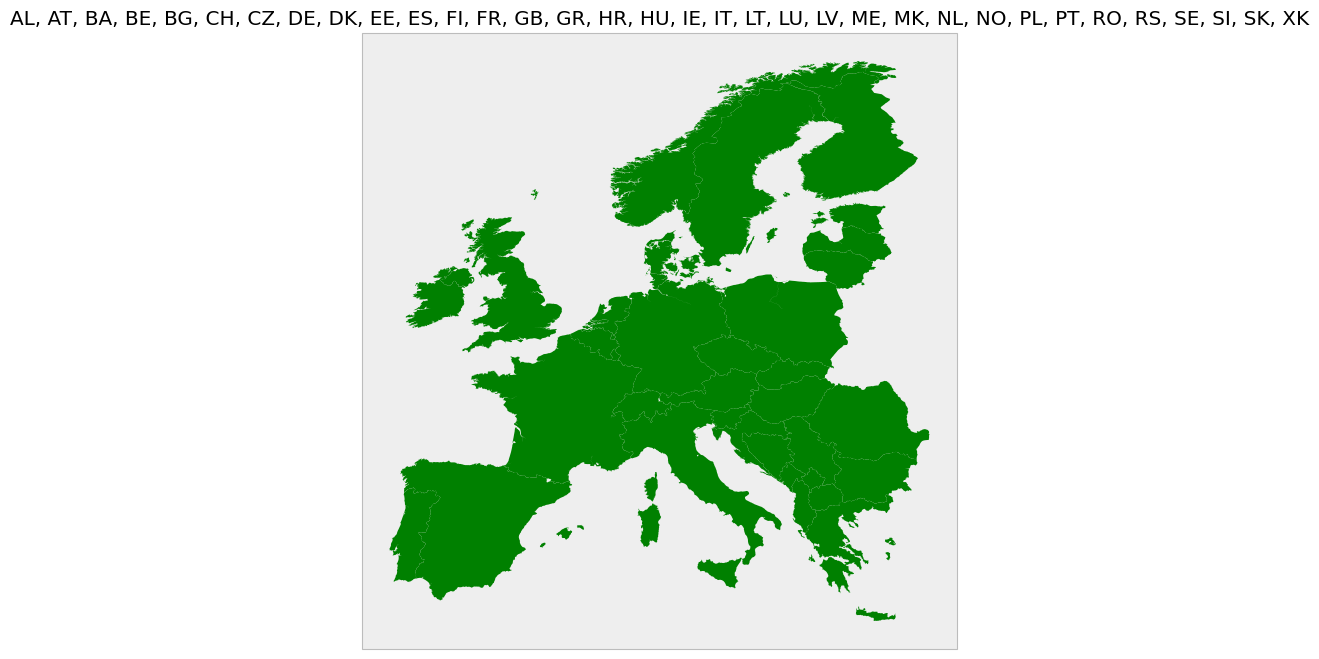

In [5]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [145]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 1547 entries
Component 'Carrier' has 102 entries
Component 'GlobalConstraint' has 2 entries
Component 'Line' has 257 entries
Component 'LineType' has 36 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 8198 entries
Component 'Load' has 1283 entries
Component 'Generator' has 1978 entries
Component 'StorageUnit' has 137 entries
Component 'Store' has 997 entries


Snapshot check

In [146]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01', '2013-01-07', '2013-01-13', '2013-01-19',
               '2013-01-25', '2013-01-31', '2013-02-06', '2013-02-12',
               '2013-02-18', '2013-02-24', '2013-03-02', '2013-03-08',
               '2013-03-14', '2013-03-20', '2013-03-26', '2013-04-01',
               '2013-04-07', '2013-04-13', '2013-04-19', '2013-04-25',
               '2013-05-01', '2013-05-07', '2013-05-13', '2013-05-19',
               '2013-05-25', '2013-05-31', '2013-06-06', '2013-06-12',
               '2013-06-18', '2013-06-24', '2013-06-30', '2013-07-06',
               '2013-07-12', '2013-07-18', '2013-07-24', '2013-07-30',
               '2013-08-05', '2013-08-11', '2013-08-17', '2013-08-23',
               '2013-08-29', '2013-09-04', '2013-09-10', '2013-09-16',
               '2013-09-22', '2013-09-28', '2013-10-04', '2013-10-10',
               '2013-10-16', '2013-10-22', '2013-10-28', '2013-11-03',
               '2013-11-09', '2013-11-15', '2013-11-21', '2013-11-27',
      

## Analyse energy system

Analyse the current capacity of the energy system - map view

In [147]:
default_color = '#000000'
# Set a default color for empty entries
n.carriers.color = n.carriers.color.replace('', default_color)


/home/alex-charly/anaconda3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_60521/3677568634.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


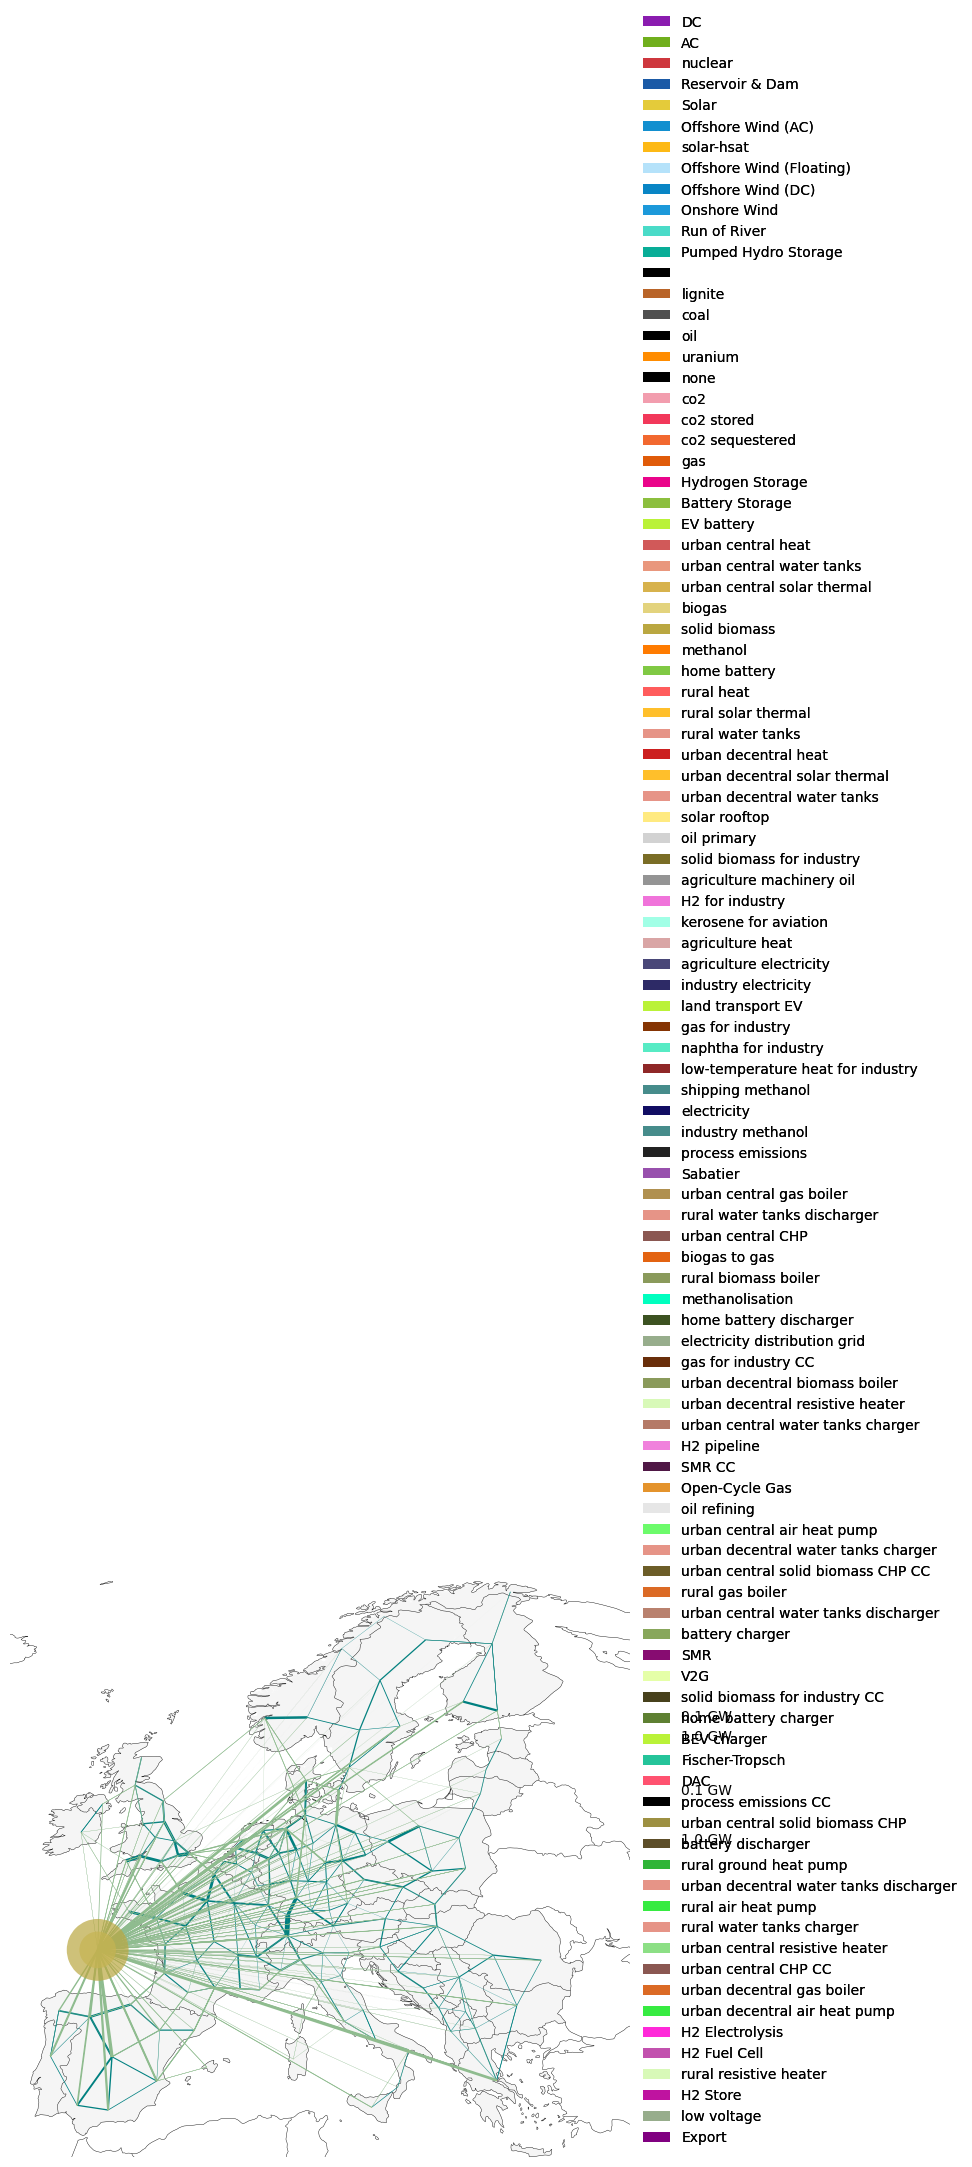

In [148]:
# Scale settings
bus_scale = 2e8
line_scale = 1e4

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

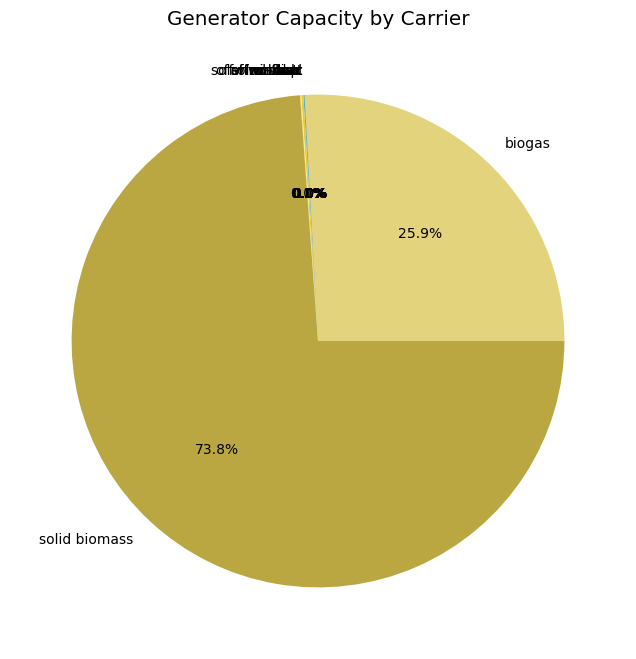

In [149]:
generator_capacity_by_carrier = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["carrier"]).p_nom.sum()
plt.figure(figsize=(8, 8))
# Filter out carriers with zero capacity
filtered_capacity = generator_capacity_by_carrier[generator_capacity_by_carrier > 0]
# Get the corresponding colors
filtered_colors = n.carriers[n.carriers.index.isin(filtered_capacity.index)].color.reindex(filtered_capacity.index)
# Plot the pie chart
plt.pie(filtered_capacity, labels=filtered_capacity.index, autopct='%1.1f%%', colors=filtered_colors)
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [150]:
generator_capacity_by_carrier/1e3 # in GW

carrier
biogas                           3.593675e+05
coal                             0.000000e+00
gas                              0.000000e+00
lignite                          0.000000e+00
nuclear                          1.052861e+02
offwind-ac                       3.164423e+01
offwind-dc                       1.146364e+02
offwind-float                    1.464032e+00
oil primary                      0.000000e+00
onwind                           6.732595e+02
ror                              4.780433e+01
rural solar thermal              0.000000e+00
solar                            2.017186e+03
solar rooftop                    8.359368e+02
solar-hsat                       2.404825e+02
solid biomass                    1.025547e+06
urban central solar thermal      0.000000e+00
urban decentral solar thermal    0.000000e+00
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/alex-charly/anaconda3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_60521/958174134.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


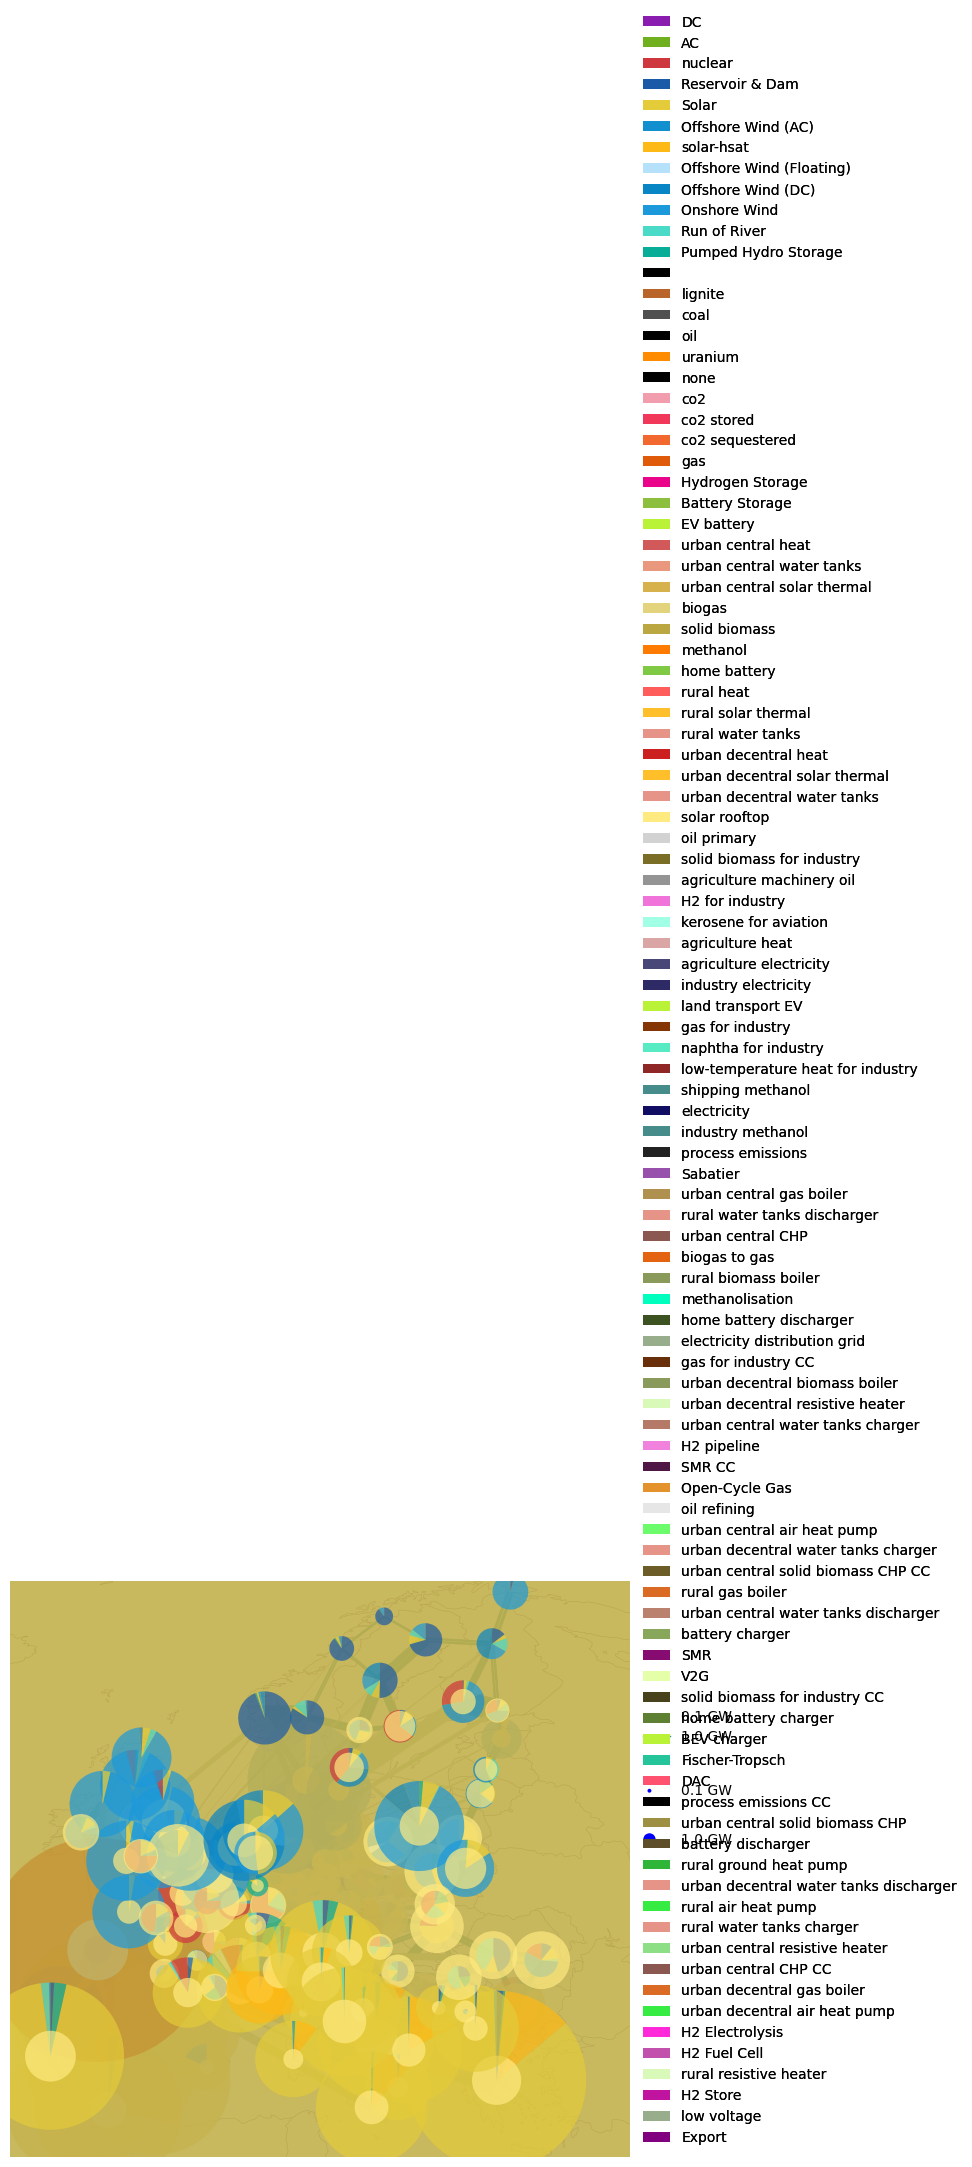

In [151]:
bus_scale = 5e3 
line_scale = 1e3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Calculate emissions of future energy system

In [152]:
co2_emissions = pd.DataFrame(data=n.carriers[["co2_emissions", "nice_name"]]).set_index("nice_name").squeeze().rename_axis("carrier")

energy_production = n.statistics.energy_balance().Generator.droplevel(1).drop(["load", "export"], errors="ignore")

co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index]
co2_emissions_technology

carrier
Offshore Wind (AC)               0.0
Offshore Wind (DC)               0.0
Offshore Wind (Floating)         0.0
Onshore Wind                     0.0
Run of River                     0.0
Solar                            0.0
biogas                           0.0
coal                             0.0
gas                              0.0
lignite                          0.0
nuclear                          0.0
oil primary                      0.0
rural solar thermal              0.0
solar rooftop                    0.0
solar-hsat                       0.0
solid biomass                    0.0
urban central solar thermal      0.0
urban decentral solar thermal    0.0
dtype: float64

In [153]:
co2_emissions_sum = co2_emissions_technology.sum()
co2_emissions_sum

0.0

In [154]:
n.global_constraints

,type,investment_period,carrier_attribute,sense,constant,mu
GlobalConstraint,,,,,,
CO2Limit,co2_atmosphere,NaN,co2_emissions,<=,0.0,-260.883972
co2_sequestration_limit,operational_limit,NaN,co2 sequestered,>=,-200000000.0,149.018656


Analys the future generation capacity expansion of the energy system - bar chart

<Axes: title={'center': 'Generator capacity expansion in GW'}, xlabel='carrier'>

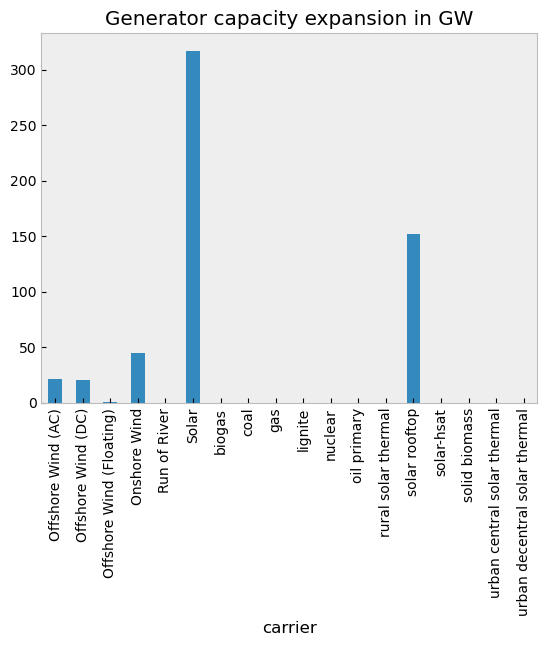

In [155]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Plot the future generation capacity expansion of the energy system - tabular chart

In [156]:
generation_capacity_expansion # In GW

carrier
Offshore Wind (AC)                21.621167
Offshore Wind (DC)                20.138685
Offshore Wind (Floating)           0.608395
Onshore Wind                      44.297880
Run of River                       0.000000
Solar                            317.110221
biogas                             0.000000
coal                                    NaN
gas                                     NaN
lignite                                 NaN
nuclear                            0.000000
oil primary                             NaN
rural solar thermal                     NaN
solar rooftop                    151.864629
solar-hsat                         0.000037
solid biomass                      0.000000
urban central solar thermal             NaN
urban decentral solar thermal           NaN
dtype: float64

Analyse the future energy generation of the energy system - bar chart view

In [157]:
# Color for figure
n.carriers.loc["H2 electrolysis", "nice_name"] = "H2 Electrolysis"
n.carriers.loc["H2 electrolysis", "color"] = "#ea048a"
n.carriers.loc["H2 fuel cell", "nice_name"] = "H2 Fuel Cell"
n.carriers.loc["H2 fuel cell", "color"] = "#ea048a"
n.carriers.loc["battery charger", "nice_name"] = "Battery Charger"
n.carriers.loc["battery charger", "color"] = rgb_to_hex(140,191,62)
n.carriers.loc["battery discharger", "nice_name"] = "Battery Discharger"
n.carriers.loc["battery discharger", "color"] = rgb_to_hex(140,191,62)
n.carriers.loc["load", "nice_name"] = "Load"
n.carriers.loc["load", "color"] = "#8b0000"

In [158]:
# Set the index of n.carriers to nice_name
color_setting = n.carriers.set_index('nice_name')

# Calculate energy balance
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().sort_values(ascending=False).div(1e6).to_frame().T
#energy_balance.drop(columns=["Load"], inplace=True)
energy_balance.rename(columns={'-': 'Load'}, inplace=True)

# Get the colors for the carriers
colors = color_setting.loc[energy_balance.columns, 'color']

# Plot the bar chart with colors
fig, ax = plt.subplots()
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh", color=colors)

# Adjust legend
ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

plt.show()


KeyError: "['CCGT'] not in index"

Analyse the future energy generation of the energy system - tabular view

In [159]:
n.statistics.energy_balance()/1e6 # In TWh

KeyboardInterrupt: 

In [160]:
n.statistics.energy_balance().Load

carrier                            bus_carrier               
H2 for industry                    Hydrogen Storage             -1.796700e+08
agriculture electricity            low voltage                  -3.752588e+07
agriculture heat                   rural heat                   -2.148117e+08
agriculture machinery oil          agriculture machinery oil    -1.028476e+08
electricity                        low voltage                  -1.574888e+09
gas for industry                   gas for industry             -2.313800e+08
industry electricity               low voltage                  -1.769360e+09
industry methanol                  industry methanol            -8.730000e+06
kerosene for aviation              kerosene for aviation        -7.439070e+08
land transport EV                  EV battery                   -9.796810e+08
low-temperature heat for industry  urban central heat           -5.917000e+07
                                   urban decentral heat         -2.200000e+05
na

## Analyse pv and wind potential - map view

In [83]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"/mnt/e/H2GMA/Github/Europe/pypsa-eur/resources/myopic/{run_name}/regions_{voronoi}_base_s_{cluster}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot pv energy potential

INFO:pypsa.io:Imported network base.nc has buses, carriers, lines, links, shapes, transformers


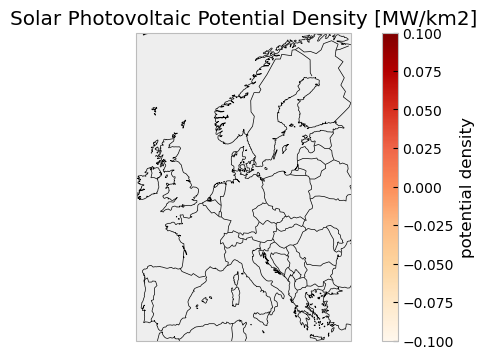

In [ ]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot wind energy potential

INFO:pypsa.io:Imported network base.nc has buses, carriers, lines, links, shapes, transformers


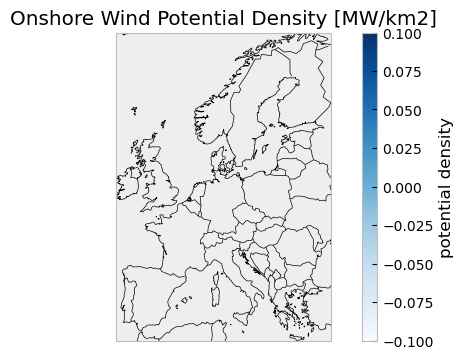

In [85]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Levelized cost of electricity

In [ ]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity generation
# n.statistics.market_value() ?
lcoe = n.objective/n.statistics.energy_balance().Generator.sum()
lcoe 

In [ ]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity demand
lcoe = n.objective/n.statistics.energy_balance().Load.sum()*(-1)
lcoe 

Average THG value

In [ ]:
THG_Strom = co2_emissions_technology.sum()/n.statistics.energy_balance().Generator.sum()
THG_Strom #t CO2/MWh Strom bzw. kg CO2/kWh Strom
THG_H2 = THG_Strom/0.65 #Wirkungsgrad Elektrolyseur
THG_H2 #kg CO2/kWh H2
THG_H2 = THG_H2*33.33 #kWh/kg
THG_H2 # kg CO2/kg H2

### H2-Demand-Europe

In [168]:
df_h2_eu = n.statistics.energy_balance().loc[:, :, "Hydrogen Storage"].div(1e6)
df_h2_eu

component  carrier        
Link       Fischer-Tropsch   -1305.444699
           H2 Electrolysis    2028.399641
           H2 Fuel Cell         -0.000016
           SMR                   0.000024
           SMR CC               39.045396
           Sabatier             -0.000041
           methanolisation    -582.280306
Load       H2 for industry    -179.720000
dtype: float64

In [169]:
df_h2_eu[df_h2_eu < 0].sum()

-2067.4450607372396

### H2-Demand-Germany

In [170]:
df_h2_de = n.statistics.energy_balance(groupby=["carrier", "bus_carrier", "country"])
df_h2_de

component  carrier               bus_carrier           country
Generator  Offshore Wind (AC)    AC                    AL         6.816000e-02
                                                       BA         2.313000e-02
                                                       BE         3.749759e+06
                                                       BG         2.368000e-01
                                                       DE         1.824150e+07
                                                                      ...     
Load       urban decentral heat  urban decentral heat  RS        -4.042778e+06
                                                       SE        -2.753379e+07
                                                       SI        -2.077078e+06
                                                       SK        -5.571043e+06
                                                       XK        -6.369583e+05
Length: 3570, dtype: float64

In [173]:
df_h2_de = n.statistics.energy_balance(groupby=["carrier", "bus_carrier", "country"])
idx = pd.IndexSlice
df_h2_de = df_h2_de.loc[idx[:,:,"Hydrogen Storage",:]].div(1e6)

In [174]:
df_h2_de[df_h2_de < 0].sum()

-2159.59992536154

In [178]:
n.loads.to_csv("load.csv")

In [183]:
# Filter loads that are connected to buses containing "DE"
de_loads = n.loads[n.loads.bus.str.contains("DE")]

In [188]:
de_loads_t = n.loads_t.p.loc[:, n.loads_t.p.columns.str.contains("DE")]
de_loads_t


Load,DE0 0,DE0 0 H2 for industry,DE0 0 agriculture electricity,DE0 0 agriculture heat,DE0 0 industry electricity,DE0 0 land transport EV,DE0 0 low-temperature heat for industry,DE0 0 rural heat,DE0 0 urban central heat,DE0 0 urban decentral heat,...,DE0 9,DE0 9 H2 for industry,DE0 9 agriculture electricity,DE0 9 agriculture heat,DE0 9 industry electricity,DE0 9 land transport EV,DE0 9 low-temperature heat for industry,DE0 9 rural heat,DE0 9 urban central heat,DE0 9 urban decentral heat
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01,467.164382,0.0,3.714516,25.78528,512.557078,171.515813,10.273973,574.336371,62.542144,36.256316,...,853.707986,1640.410959,22.159004,153.822509,3948.630137,997.694849,76.484018,197.777116,2390.002201,1385.508522
2013-01-07,576.692299,0.0,3.714516,25.78528,512.557078,183.883177,10.273973,729.625472,79.452293,46.059300,...,1045.962741,1640.410959,22.159004,153.822509,3948.630137,1072.848980,76.484018,281.825866,3405.674296,1974.303940
2013-01-13,591.314743,0.0,3.714516,25.78528,512.557078,190.523962,10.273973,990.146773,107.821663,62.505312,...,1022.765647,1640.410959,22.159004,153.822509,3948.630137,1126.296515,76.484018,437.470523,5286.534331,3064.657583
2013-01-19,583.553277,0.0,3.714516,25.78528,512.557078,183.201371,10.273973,1015.472659,110.579515,64.104067,...,1003.272168,1640.410959,22.159004,153.822509,3948.630137,1082.007919,76.484018,449.830697,5435.898638,3151.245587
2013-01-25,570.261624,0.0,3.714516,25.78528,512.557078,177.401180,10.273973,794.959597,86.566828,50.183668,...,1033.893761,1640.410959,22.159004,153.822509,3948.630137,1027.935318,76.484018,288.074476,3481.184510,2018.077977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-03,606.893718,0.0,3.714516,25.78528,512.557078,177.731283,10.273973,751.184304,81.799934,47.420252,...,1105.674195,1640.410959,22.159004,153.822509,3948.630137,1033.480305,76.484018,286.682111,3464.358716,2008.323893
2013-12-09,615.304167,0.0,3.714516,25.78528,512.557078,181.296452,10.273973,654.544949,71.276427,41.319668,...,1121.716534,1640.410959,22.159004,153.822509,3948.630137,1069.469028,76.484018,276.504627,3341.370740,1937.026516
2013-12-15,592.685428,0.0,3.714516,25.78528,512.557078,179.621945,10.273973,688.820619,75.008864,43.483399,...,1105.780826,1640.410959,22.159004,153.822509,3948.630137,1028.518144,76.484018,211.892158,2560.572904,1484.390089
